# The Unreasonable Effectiveness of Data for Recommender Systems
[add a description/summary/abstract here later]

## 1. Environment
Setting up or checking the current environment

### 1.1. Setup (Pip)
Install all required libraries.

Note: these older Numpy and Torch versions are needed otherwise Recbole (v1.2.1) breaks

In [ ]:
# Core packages
!pip install -U pip
!pip install numpy==1.26.4
!pip install pandas==2.3.1
!pip install torch==2.5.1
!pip install scikit-learn==1.7.1
!pip install matplotlib==3.10.3

# Recommender system packages
!pip install lenskit==2025.2.0
!pip install recbole==1.2.1
# !pip install lenskit==0.14.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 24.0 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


KeyboardInterrupt: 

### 1.2. Python Version
Check python version (only 3.11 works atm)

In [ ]:
!python --version

Python 3.11.0


### 1.3. Pip list
Keep this cell's output in case the full list of package versions that are known to work can be revisited

In [ ]:
!pip list

Package                   Version
------------------------- ----------------
absl-py                   2.3.1
aiosignal                 1.4.0
annotated-types           0.7.0
asttokens                 3.0.0
attrs                     25.3.0
certifi                   2025.7.14
charset-normalizer        3.4.2
click                     8.2.1
colorama                  0.4.4
colorlog                  4.7.2
comm                      0.2.2
contourpy                 1.3.2
cycler                    0.12.1
debugpy                   1.8.15
decorator                 5.2.1
executing                 2.2.0
filelock                  3.18.0
fonttools                 4.59.0
frozenlist                1.7.0
fsspec                    2025.7.0
grpcio                    1.73.1
humanize                  4.12.3
idna                      3.10
ipykernel                 6.30.0
ipython                   9.4.0
ipython_pygments_lexers   1.1.1
jedi                      0.19.2
Jinja2                    3.1.6
joblib      

### 1.4. GPU Check
Use torch to check if GPU(s) is/are availabe in the current environment

In [ ]:
import torch
import os


print("=== GPU Detection ===")
print("CUDA available:", torch.cuda.is_available())
print("Number of GPUs:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("\n=== GPU Details ===")
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f"\nGPU {i}:")
        print(f"  Name: {props.name}")
        print(f"  Memory: {props.total_memory / 1024**3:.1f} GB")
        print(f"  Compute Capability: {props.major}.{props.minor}")
        print(f"  Multi-processors: {props.multi_processor_count}")

        # Test GPU accessibility
        try:
            torch.cuda.set_device(i)
            test_tensor = torch.tensor([1.0]).cuda()
            print(f"  Status: ✓ Accessible")
        except Exception as e:
            print(f"  Status: ✗ Error - {e}")

    print(f"\n=== Current GPU ===")
    print(f"Current device: {torch.cuda.current_device()}")
    print(f"Current device name: {torch.cuda.get_device_name()}")

    print(f"\n=== Environment Variables ===")
    print(f"CUDA_VISIBLE_DEVICES: {os.environ.get('CUDA_VISIBLE_DEVICES', 'Not set')}")

else:
    print("No CUDA GPUs detected")


### 1.5. Google Drive (For Google Colab)


#### 1.5.1. Mount and Copy
Mount Google Drive and copy the required data/folders from the repository's directory

In [ ]:
import os
import shutil
from google.colab import drive


DRIVE_ROOT = "/content/drive/My Drive/Workspace/Thesis/Repository/unreasonable-effectiveness-recsys/"


drive.mount("/content/drive/", readonly=False)

source = DRIVE_ROOT
destination = "./"
directories = ["datasets/", "recbole/datasets/"]

for directory in directories:
  shutil.copytree(source + directory, destination + directory)


Mounted at /content/drive/


#### 1.5.2. Load Latest Results


In [ ]:
import yaml


DRIVE_RESULTS = DRIVE_ROOT + "results/"
DRIVE_RESULTS_LATEST = DRIVE_RESULTS + "latest.yaml"


def drive_load_results() -> dict:
  with open(DRIVE_RESULTS_LATEST, "r") as f:
    return yaml.safe_load(f)


#### 1.5.3. Save Latest Results


In [ ]:
import yaml


def drive_save_results(results: dict) -> None:
  with open(DRIVE_RESULTS_LATEST, "w") as f:
    yaml.dump(results, f)


## 2. Parameters
Global variables and shared parameters

### 2.1. Constants
Kept for consistency

In [ ]:

COLUMN_NAMES = {"user_id": "user_id", "item_id": "item_id", "rating": "rating"}
ROOT_DIRECTORY = "./"
DATASETS_DIRECTORY = ROOT_DIRECTORY + "datasets/"
RATINGS_FILE_NAME = "ratings.csv"
RESULTS_DIRECTORY = ROOT_DIRECTORY + "results/"
RESULTS_LATEST_FILE = RESULTS_DIRECTORY + "latest.yaml"


### 2.2. Experiment Variables
Fixed experiment parameters

In [ ]:

RECOMMENDATIONS = 10
SEED = 42
SIZES = [0.1, 0.25, 0.5, 0.75, 1.0] # [0.1, 0.33, 0.67, 1.0]


### 2.3. Hyperparameters
Shared hyperparameters

In [2]:

TEST_SIZE = 0.2
PARTITIONS = 5 # For cross-validation
TRAINING_RECOMMENDATIONS = 100

# KNN
KNN_K = TRAINING_RECOMMENDATIONS
KNN_MIN_K = 5

# Matrix Factorization
FEATURES = 50


## 3. Load
Load the desired dataset as a Pandas DataFrame of user ID, item ID, and rating in that order

In [30]:
from enum import Enum
import pandas as pd


class Dataset(Enum):
  MOVIELENS = "movielens"
  GOODREADS = "goodreads"
  AMAZON = "amazon"
  MOVIETWEETINGS = "movietweetings"
  PERSONALITY = "personality"

def load(dataset: Dataset = Dataset.MOVIELENS) -> pd.DataFrame:
  path = f"{DATASETS_DIRECTORY}{dataset.value}/{RATINGS_FILE_NAME}"
  df = pd.read_csv(path, sep=',', usecols=[0, 1, 2], names=[
    COLUMN_NAMES["user_id"],
    COLUMN_NAMES["item_id"],
    COLUMN_NAMES["rating"]
  ])
  df = df.reset_index(drop=True)
  return df


## 4. Sample
Take a sample of size N within the globally defined range

In [4]:
import pandas as pd


def sample(df: pd.DataFrame, size: float = SIZES[(len(SIZES) // 2) - 1]) -> pd.DataFrame:
  if size not in SIZES:
    raise ValueError(f"Size must be one of '{SIZES}'")

  size = int(size * len(df))
  return df.sample(size, random_state=SEED)


## 5. Split (unused)
Data-frame splitting

### 5.1. Horizontal split (unused)
Split the data-frame into training and testing data-frames

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split


def horizontal_split(df: pd.DataFrame, test_size: float = TEST_SIZE):
  return train_test_split(df, test_size=test_size, random_state=SEED)


### 5.2. Vertical split (unused)
Split the training and testing data into X and y data-frames (features and target)

In [ ]:
import pandas as pd


def vertical_split(train: pd.DataFrame, test: pd.DataFrame):
  X_train, X_test = train.drop(columns=["rating"]), test.drop(columns=["rating"])
  y_train, y_test = train["rating"], test["rating"]
  return X_train, X_test, y_train, y_test


## 6. Recommend
Use Recommender System (RecSys) tools/libraries to train, predict, and evaluate a given (sampled) dataset

### 6.1. LensKit
Use LensKit to train and evaluate a given data-frame returning a single float of the mean NDCG

In [14]:
from enum import Enum
import pandas as pd
from lenskit.data import from_interactions_df, UserIDKey, ItemListCollection
from lenskit.splitting import SampleFrac, crossfold_users, sample_records
from lenskit.knn import ItemKNNScorer, ItemKNNConfig, UserKNNScorer, UserKNNConfig
from lenskit.als import BiasedMFScorer
from lenskit.pipeline import topn_pipeline, RecPipelineBuilder
from lenskit.batch import recommend
from lenskit.metrics import RunAnalysis, NDCG
from lenskit.basic import BiasScorer


class Scorer(Enum):
  ITEM_KNN = 0
  BIASED_MF = 1
  # USER_KNN = 2
  # BIAS = 3

SCORERS = {
  Scorer.ITEM_KNN.name: lambda: ItemKNNScorer(ItemKNNConfig(
    max_nbrs=KNN_K, min_nbrs=KNN_MIN_K, feedback="explicit",
  )),
  Scorer.BIASED_MF.name: lambda: BiasedMFScorer(features=FEATURES),
  # Scorer.USER_KNN.name: lambda: UserKNNScorer(UserKNNConfig(
  #   max_nbrs=KNN_K, min_nbrs=KNN_MIN_K, feedback="explicit",
  # )),
  # Scorer.BIAS.name: lambda: BiasScorer(),
}

def use_lenskit(df: pd.DataFrame, scorer: Scorer = Scorer.ITEM_KNN) -> float:
  dataset = from_interactions_df(
    df,
    user_col=COLUMN_NAMES["user_id"],
    item_col=COLUMN_NAMES["item_id"],
    rating_col=COLUMN_NAMES["rating"],
    timestamp_col=None,
  )

  get = SCORERS[scorer.name]
  model = get()

  pipe = topn_pipeline(model, n=TRAINING_RECOMMENDATIONS, predicts_ratings=True)

  all_test = ItemListCollection.empty([COLUMN_NAMES["user_id"]])
  all_recs = ItemListCollection.empty([COLUMN_NAMES["user_id"]])

  split = sample_records(dataset, size=int(dataset.interaction_count * TEST_SIZE), repeats=None, rng=SEED)
  all_test.add_from(split.test)
  fit = pipe
  fit.train(split.train)
  recs = recommend(fit, split.test.keys(), n=RECOMMENDATIONS)
  all_recs.add_from(recs)

  ran = RunAnalysis()
  ran.add_metric(NDCG(k=RECOMMENDATIONS, gain=COLUMN_NAMES["rating"]))
  results = ran.measure(all_recs, all_test)
  result = results.list_summary().iloc[0].iloc[0]

  return float(result)


### 6.2. RecBole
Use RecBole to train and evaluate a given data-frame returning a single float of the mean NDCG

#### 6.2.1. Parameters
Recbole specific parameters and shared variables

In [15]:
RECBOLE_ROOT_DIRECTORY = "./artifacts/recbole/"
RECBOLE_DATASETS_DIRECTORY = RECBOLE_ROOT_DIRECTORY + "datasets/"
RECBOLE_CHECKPOINTS_DIRECTORY = RECBOLE_ROOT_DIRECTORY + "checkpoints/"
RECBOLE_DEFAULT_DATASET_NAME = "data"
RECBOLE_DEFAULT_DATASET_FILE_NAME = f"{RECBOLE_DEFAULT_DATASET_NAME}.inter"

RECBOLE_CONFIG = {
  # Environment
  "seed": SEED,
  "data_path": None, # Assigned at runtime
  "checkpoint_dir": None, # Assigned at runtime

  # Data
  "field_separator": ',',
  "seq_separator": '\n',
  "USER_ID_FIELD": COLUMN_NAMES["user_id"],
  "ITEM_ID_FIELD": COLUMN_NAMES["item_id"],
  "RATING_FIELD": COLUMN_NAMES["rating"],
  "TIME_FIELD": None,
  "load_col": {"inter": [COLUMN_NAMES["user_id"], COLUMN_NAMES["item_id"], COLUMN_NAMES["rating"]]},

  # Training
  ##########

  # Evaluation
  "eval_args": {
    "split": {"RS": [10 - (TEST_SIZE * 10), 0, (TEST_SIZE * 10)]},
  },
  "metrics": ["NDCG"],
  "topk": RECOMMENDATIONS,

  # Hyper Parameters
  ## KNN
  "k": KNN_K
}

#### 6.2.2. Prepare
Save the interactions data-frame as an "Atomic" (CSV-like) .inter file

In [ ]:
import pandas as pd
import os


def save_as_atomic(df: pd.DataFrame, dataset: Dataset) -> None:
  path = f"{RECBOLE_DATASETS_DIRECTORY}{dataset.value}/{RECBOLE_DEFAULT_DATASET_FILE_NAME}"
  checkpoint = f"{RECBOLE_CHECKPOINTS_DIRECTORY}{dataset.value}/"
  try:
    os.makedirs(os.path.dirname(path), exist_ok=False)
    os.makedirs(os.path.dirname(checkpoint), exist_ok=True)
  except OSError:
    return None
  with open(path, "w") as f:
    features = [f"{name}:float" if name == COLUMN_NAMES["rating"] else f"{name}:token" for name in df.columns]
    f.write(','.join(features) + '\n')
  df.to_csv(path, mode="a", index=False, header=False)

#### 6.2.3. Run
Create the atomic file, call "run_recbole" using the config dictionary, and returns the NDCG@[RECOMMENDATIONS] as well

In [ ]:
from enum import Enum
import pandas as pd
from recbole.quick_start import run_recbole
import copy


class Model(Enum):
  ITEM_KNN = "ItemKNN"  # Item K-Nearest Neighbours
  POPULARITY = "Pop"  # Popularity
  FACTORED_ITEM_SIMILARITY = "FISM"  # Factored Item Similarity Models
  NEURAL_ATTENTIVE_ITEM_SIMILARITY = "NAIS"  # Neural Attentive Item Similarity Model


def use_recbole(df: pd.DataFrame, dataset: Dataset, model: Model = Model.ITEM_KNN) -> float:
  save_as_atomic(df, dataset)

  config = copy.deepcopy(RECBOLE_CONFIG)
  config["data_path"] = f"{RECBOLE_DATASETS_DIRECTORY}{dataset.value}/"
  config["checkpoint_dir"] = f"{RECBOLE_CHECKPOINTS_DIRECTORY}{dataset.value}/"
  
  result = run_recbole(model=model.value, dataset=RECBOLE_DEFAULT_DATASET_NAME, config_dict=config)

  test_result = result["test_result"]
  for key, value in test_result.items():
    if "ndcg" in key.lower():
      return float(value)
  raise ValueError("No NDCG metric found")


## 7. Plot
Graph plotting and vizualisation of results

### 7.1. Types
Type definitions for shared types

In [24]:
from typing import Dict, TypeAlias
# from pydantic import BaseModel, ValidationError

# d[library][algorithm][dataset][size] -> float
Results: TypeAlias = Dict[str, Dict[str, Dict[str, Dict[str, float]]]]

### 7.2. Prepare
Prepare and return a dictionary that would hold the results

In [25]:

# Dictionary so that 'd[library][algorithm][dataset][size] -> float' holds the NDCG
def prepare_results(sizes = SIZES, libraries = ["LensKit", "RecBole"]) -> Results:
  results = {
    library: {
      algorithm.name: {
        dataset.name: {
          str(int(size * 100.0)) + '%': float(-1) for size in sizes
        } for dataset in Dataset
      } for algorithm in (Scorer if library == "LensKit" else Model)
    } for library in libraries
  }
  return results


### 7.3. Plot Results
Handle a given 'Results' dictionary instance

In [26]:
import matplotlib.pyplot as plt


MARKERS = ['o', '^', '2', 's', 'P', '*', 'X', 'D', '|']
COLORS = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple",
          "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]

def plot_results(results: Results, figsize=(10, 12)) -> None:
  # Setup
  libraries = list(results.keys())
  fig, axes = plt.subplots(len(libraries), 1, figsize=figsize)

  # If only one library, make axes iterable
  if len(libraries) == 1:
    axes = [axes]

  for library_index, library in enumerate(libraries):
    ax = axes[library_index]

    algorithms = list(results[library].keys())
    datasets = list(results[library][algorithms[0]].keys())  # Get datasets from first algorithm

    # Plot each algorithm-dataset combination
    for algorithm_index, algorithm in enumerate(algorithms):
      for dataset_index, dataset in enumerate(datasets):
        # Extract sizes and values
        size_value = results[library][algorithm][dataset]
        size_value = dict(sorted(size_value.items(), key=lambda item: int(item[0].rstrip('%'))))
        sizes = list(size_value.keys())
        values = list(size_value.values())
        values = [value if value > 0 else 0 for value in values]

        marker = MARKERS[algorithm_index]
        color = COLORS[dataset_index]

        ax.plot(
          sizes, values,
          color=color,
          marker=marker,
          linewidth=2,
          markersize=10,
          label=f'{algorithm.capitalize()} - {dataset.capitalize()}',
        )

        # Customize subplot
        ax.set_title(library, fontsize=14, fontweight="bold")
        ax.set_xlabel("Dataset Size", fontsize=12)
        ax.set_ylabel(f"NDCG@{RECOMMENDATIONS}", fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

        # Set x-axis to log scale if sizes vary widely
        # if max(sizes) / min(sizes) > 10:
        #     ax.set_xscale("log")

  plt.tight_layout()
  plt.show()


### 7.4. Load Results
Loads the latest results yaml file (currently local)

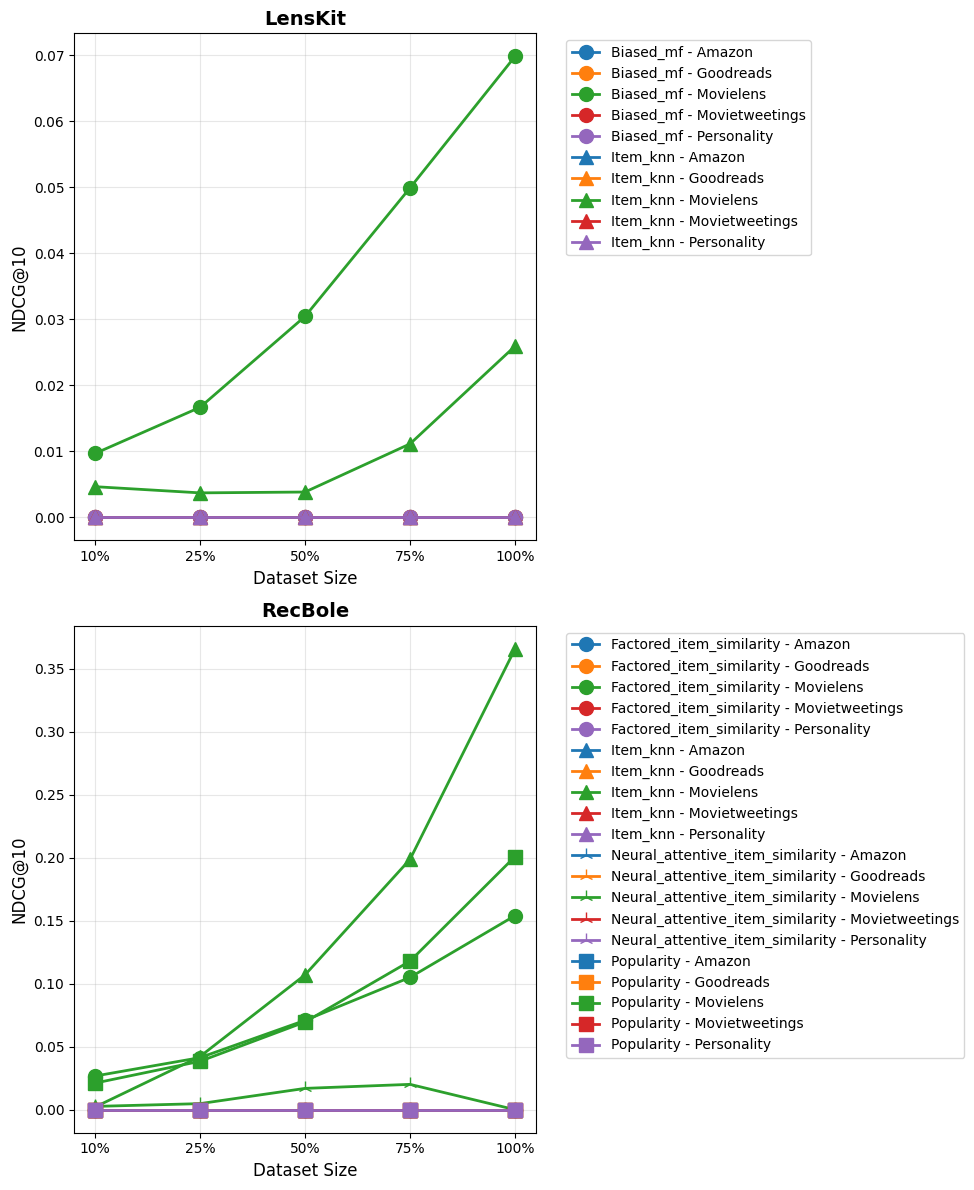

In [29]:
import yaml


def load_results(google_drive=False) -> Results:
  results: Results
  if google_drive:
    results = drive_load_results()
  else:
    with open(RESULTS_LATEST_FILE, "r") as f:
      results = yaml.safe_load(f)
  return results

plot_results(load_results())

### 7.5. Save Results
Saves (overwrites) given results to the latest results yaml file (currently on Google Drive)

In [28]:
import yaml


def save_results(results: Results, google_drive=False) -> None:
  if google_drive:
    drive_save_results(results)
  else:
    with open(RESULTS_LATEST_FILE, "w") as f:
      yaml.dump(results, f)


## 8. Run
Execute using the above function and variable definitions

In [ ]:

lenskit = "LensKit"
recbole = "RecBole"
sizes = SIZES
# results = prepare_results(sizes)
results = load_results()

for dataset in Dataset:
  full = load(dataset)

  for size in sizes:
    sampled = sample(full, size)
    percentage = f"{int(size * 100)}%"

    # LensKit
    for scorer in Scorer:
      if results[lenskit][scorer.name][dataset.name][percentage] < 0.0:
        result = use_lenskit(sampled, scorer)
        results[lenskit][scorer.name][dataset.name][percentage] = result
        save_results(results)
      else:
        print(f"Skipping [LensKit][{scorer.name}][{dataset.name}][{percentage}]")

    # RecBole
    for model in Model:
      if results[recbole][model.name][dataset.name][percentage] < 0.0:
        result = use_recbole(sampled, dataset, model)
        results[recbole][model.name][dataset.name][percentage] = result
        save_results(results)
      else:
        print(f"Skipping [RecBole][{model.name}][{dataset.name}][{percentage}]")

plot_results(results)


Skipping [LensKit][ITEM_KNN][MOVIELENS][10%]
Skipping [LensKit][BIASED_MF][MOVIELENS][10%]
Skipping [RecBole][ITEM_KNN][MOVIELENS][10%]
Skipping [RecBole][POPULARITY][MOVIELENS][10%]
Skipping [RecBole][FACTORED_ITEM_SIMILARITY][MOVIELENS][10%]
Skipping [RecBole][NEURAL_ATTENTIVE_ITEM_SIMILARITY][MOVIELENS][10%]
Skipping [LensKit][ITEM_KNN][MOVIELENS][25%]
Skipping [LensKit][BIASED_MF][MOVIELENS][25%]
Skipping [RecBole][ITEM_KNN][MOVIELENS][25%]
Skipping [RecBole][POPULARITY][MOVIELENS][25%]
Skipping [RecBole][FACTORED_ITEM_SIMILARITY][MOVIELENS][25%]
Skipping [RecBole][NEURAL_ATTENTIVE_ITEM_SIMILARITY][MOVIELENS][25%]
Skipping [LensKit][ITEM_KNN][MOVIELENS][50%]
Skipping [LensKit][BIASED_MF][MOVIELENS][50%]
Skipping [RecBole][ITEM_KNN][MOVIELENS][50%]
Skipping [RecBole][POPULARITY][MOVIELENS][50%]
Skipping [RecBole][FACTORED_ITEM_SIMILARITY][MOVIELENS][50%]


/usr/local/lib/python3.11/dist-packages/recbole/data/dataset/dataset.py:648: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  feat[field].fillna(value=0, inplace=True)
/usr/local/lib/python3.11/dist-packages/recbole/data/dataset/dataset.py:650: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a c

2025-07-28 00:02:42 [warning  ] loaded pipeline does not match hash


/usr/local/lib/python3.11/dist-packages/lenskit/pipeline/_impl.py:233: PipelineWarning: loaded pipeline config does not match hash
  builder = PipelineBuilder.from_config(config)
/usr/local/lib/python3.11/dist-packages/lenskit/data/relationships.py:378: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  return torch.sparse_csr_tensor(


2025-07-28 00:02:51 [warning  ] loaded pipeline does not match hash


...

/usr/local/lib/python3.11/dist-packages/lenskit/pipeline/_impl.py:233: PipelineWarning: loaded pipeline config does not match hash
  builder = PipelineBuilder.from_config(config)


2025-07-28 08:32:18 [warning  ] loaded pipeline does not match hash


/usr/local/lib/python3.11/dist-packages/lenskit/pipeline/_impl.py:233: PipelineWarning: loaded pipeline config does not match hash
  builder = PipelineBuilder.from_config(config)


2025-07-28 08:32:38 [warning  ] loaded pipeline does not match hash


/usr/local/lib/python3.11/dist-packages/lenskit/pipeline/_impl.py:233: PipelineWarning: loaded pipeline config does not match hash
  builder = PipelineBuilder.from_config(config)
/usr/local/lib/python3.11/dist-packages/recbole/data/dataset/dataset.py:648: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  feat[field].fillna(value=0, inplace=True)
/usr/local/lib/python3.11/dist-packages/recbole/data/dataset/dataset.py:650: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using 